In [93]:
import os

downloads = r"C:\Users\Kelvin\Downloads"
for f in os.listdir(downloads):
    if "Llama" in f or "Meta" in f:
        print(f)

Meta-Llama-3-70B-Instruct (1).jsonl
Meta-Llama-3-70B-Instruct.csv
Meta-Llama-3-70B-Instruct.jsonl


In [94]:
!pip install huggingface_hub

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [95]:
import sys
import subprocess
subprocess.check_call([sys.executable, "-m", "pip", "install", "huggingface_hub"])
print(sys.executable)

c:\Users\Kelvin\AppData\Local\Programs\Python\Python314\python.exe


In [96]:
print(df["pred"].value_counts(dropna=False))

pred
yes    11014
no      8986
Name: count, dtype: int64


In [97]:
print(df["ref"].value_counts(dropna=False))

ref
no     10000
yes    10000
Name: count, dtype: int64


In [98]:
import sys
import subprocess
import os
import json
import pandas as pd

# install package in the same Python as Jupyter
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "huggingface_hub"])

from huggingface_hub import hf_hub_download


file_path = hf_hub_download(
    repo_id="potsawee/halueval-llm-judges",
    repo_type="dataset",
    filename="llm-judges/Meta-Llama-3-70B-Instruct.jsonl"
)

print("Downloaded:", file_path)


with open(file_path, "r", encoding="utf-8", errors="replace") as f:
    for i in range(3):
        print(f"LINE {i+1}:", repr(f.readline()[:200]))


rows = []

with open(file_path, "r", encoding="utf-8-sig", errors="replace") as f:
    content = f.read().strip()

try:
    obj = json.loads(content)
    if isinstance(obj, list):
        rows = obj
    elif isinstance(obj, dict):
        
        list_found = False
        for v in obj.values():
            if isinstance(v, list):
                rows = v
                list_found = True
                break
        if not list_found:
            rows = [obj]
except:
    pass


if not rows:
    with open(file_path, "r", encoding="utf-8-sig", errors="replace") as f:
        for i, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue

            
            line = line.lstrip("\ufeff")
            if line.startswith("'") and line.endswith("'"):
                line = line[1:-1]

            try:
                rows.append(json.loads(line))
            except Exception:
                
                print(f"Skipped bad line {i}: {repr(line[:120])}")


df = pd.DataFrame(rows)

print("\nColumns:")
print(df.columns.tolist())

print("\nShape:")
print(df.shape)

print("\nHead:")
print(df.head())


csv_path = r"C:\Users\Kelvin\Downloads\Meta-Llama-3-70B-Instruct.csv"
df.to_csv(csv_path, index=False, encoding="utf-8")

print("\nCSV saved at:")
print(csv_path)

Downloaded: C:\Users\Kelvin\.cache\huggingface\hub\datasets--potsawee--halueval-llm-judges\snapshots\158ceff2747c814cb5a8e00a8182c9607345ab34\llm-judges\Meta-Llama-3-70B-Instruct.jsonl
LINE 1: '[\n'
LINE 2: '    {\n'
LINE 3: '        "i": "0",\n'

Columns:
['i', 'llm_judge', 'dialogue_history', 'response', 'ref', 'pred', 'logit_yes', 'logit_no']

Shape:
(20000, 8)

Head:
   i                             llm_judge  \
0  0  meta-llama/Meta-Llama-3-70B-Instruct   
1  0  meta-llama/Meta-Llama-3-70B-Instruct   
2  1  meta-llama/Meta-Llama-3-70B-Instruct   
3  1  meta-llama/Meta-Llama-3-70B-Instruct   
4  2  meta-llama/Meta-Llama-3-70B-Instruct   

                                    dialogue_history  \
0  [Human]: Do you like Iron Man [Assistant]: Sur...   
1  [Human]: Do you like Iron Man [Assistant]: Sur...   
2  [Human]: Could you recommend any books like Th...   
3  [Human]: Could you recommend any books like Th...   
4  [Human]: Do you like Michael Jackson? [Assista...   

            

In [99]:
import pandas as pd


csv_path = r"C:\Users\Kelvin\Downloads\Meta-Llama-3-70B-Instruct.csv"
df = pd.read_csv(csv_path)


print(df.head())
print(df.columns)
print(df.shape)

data = df[["response", "ref"]].copy()


data["label"] = data["ref"].map({"yes": 1, "no": 0})

print(data.head())
print(data["label"].value_counts())

   i                             llm_judge  \
0  0  meta-llama/Meta-Llama-3-70B-Instruct   
1  0  meta-llama/Meta-Llama-3-70B-Instruct   
2  1  meta-llama/Meta-Llama-3-70B-Instruct   
3  1  meta-llama/Meta-Llama-3-70B-Instruct   
4  2  meta-llama/Meta-Llama-3-70B-Instruct   

                                    dialogue_history  \
0  [Human]: Do you like Iron Man [Assistant]: Sur...   
1  [Human]: Do you like Iron Man [Assistant]: Sur...   
2  [Human]: Could you recommend any books like Th...   
3  [Human]: Could you recommend any books like Th...   
4  [Human]: Do you like Michael Jackson? [Assista...   

                                            response  ref pred  logit_yes  \
0  I like crime fiction! Didn't know RDJ was in t...   no   no     16.000   
1  I'm not a fan of crime movies, but I did know ...  yes  yes     25.875   
2  yes and he also produced White Oleander and it...   no  yes     23.500   
3  No, I don't think Hunt Lowry was involved in A...  yes   no     23.125   
4

In [100]:
import re

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

data["clean_text"] = data["response"].apply(clean_text)

print(data[["response", "clean_text", "label"]].head())

                                            response  \
0  I like crime fiction! Didn't know RDJ was in t...   
1  I'm not a fan of crime movies, but I did know ...   
2  yes and he also produced White Oleander and it...   
3  No, I don't think Hunt Lowry was involved in A...   
4  Yes, Healing the World is one of my favorite s...   

                                          clean_text  label  
0  i like crime fiction didn t know rdj was in th...      0  
1  i m not a fan of crime movies but i did know t...      1  
2  yes and he also produced white oleander and it...      0  
3  no i don t think hunt lowry was involved in a ...      1  
4  yes healing the world is one of my favorite so...      0  


In [101]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

X = data["clean_text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1994
           1       0.78      0.74      0.76      2006

    accuracy                           0.77      4000
   macro avg       0.77      0.77      0.77      4000
weighted avg       0.77      0.77      0.77      4000



In [102]:
import pandas as pd
import re
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

csv_path = r"C:\Users\Kelvin\Downloads\Meta-Llama-3-70B-Instruct.csv"
df = pd.read_csv(csv_path)

data = df[["response", "ref"]].copy()
data["label"] = data["ref"].map({"yes": 1, "no": 0})

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

data["clean_text"] = data["response"].apply(clean_text)

X = data["clean_text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


vectorizer = TfidfVectorizer(max_features=10000)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_vec, y_train)

y_pred = model.predict(X_test_vec)


print("DF shape:", df.shape)
print("Prepared data shape:", data.shape)
print(data.head())
print(classification_report(y_test, y_pred))

DF shape: (20000, 8)
Prepared data shape: (20000, 4)
                                            response  ref  label  \
0  I like crime fiction! Didn't know RDJ was in t...   no      0   
1  I'm not a fan of crime movies, but I did know ...  yes      1   
2  yes and he also produced White Oleander and it...   no      0   
3  No, I don't think Hunt Lowry was involved in A...  yes      1   
4  Yes, Healing the World is one of my favorite s...   no      0   

                                          clean_text  
0  i like crime fiction didn t know rdj was in th...  
1  i m not a fan of crime movies but i did know t...  
2  yes and he also produced white oleander and it...  
3  no i don t think hunt lowry was involved in a ...  
4  yes healing the world is one of my favorite so...  
              precision    recall  f1-score   support

           0       0.75      0.79      0.77      1994
           1       0.78      0.74      0.76      2006

    accuracy                           0.77 

In [103]:
import pandas as pd

df = pd.read_csv("Meta-Llama-3-70B-Instruct.csv")

print(df.head())
print(df.shape)
print(df.columns)

   i                             llm_judge  \
0  0  meta-llama/Meta-Llama-3-70B-Instruct   
1  0  meta-llama/Meta-Llama-3-70B-Instruct   
2  1  meta-llama/Meta-Llama-3-70B-Instruct   
3  1  meta-llama/Meta-Llama-3-70B-Instruct   
4  2  meta-llama/Meta-Llama-3-70B-Instruct   

                                    dialogue_history  \
0  [Human]: Do you like Iron Man [Assistant]: Sur...   
1  [Human]: Do you like Iron Man [Assistant]: Sur...   
2  [Human]: Could you recommend any books like Th...   
3  [Human]: Could you recommend any books like Th...   
4  [Human]: Do you like Michael Jackson? [Assista...   

                                            response  ref pred  logit_yes  \
0  I like crime fiction! Didn't know RDJ was in t...   no   no     16.000   
1  I'm not a fan of crime movies, but I did know ...  yes  yes     25.875   
2  yes and he also produced White Oleander and it...   no  yes     23.500   
3  No, I don't think Hunt Lowry was involved in A...  yes   no     23.125   
4

In [104]:
data = df[["response","ref"]].copy()

data["label"] = data["ref"].map({
    "yes":1,
    "no":0
})

print(data.head())
print(data["label"].value_counts())

                                            response  ref  label
0  I like crime fiction! Didn't know RDJ was in t...   no      0
1  I'm not a fan of crime movies, but I did know ...  yes      1
2  yes and he also produced White Oleander and it...   no      0
3  No, I don't think Hunt Lowry was involved in A...  yes      1
4  Yes, Healing the World is one of my favorite s...   no      0
label
0    10000
1    10000
Name: count, dtype: int64


## **Univariate Analysis**     

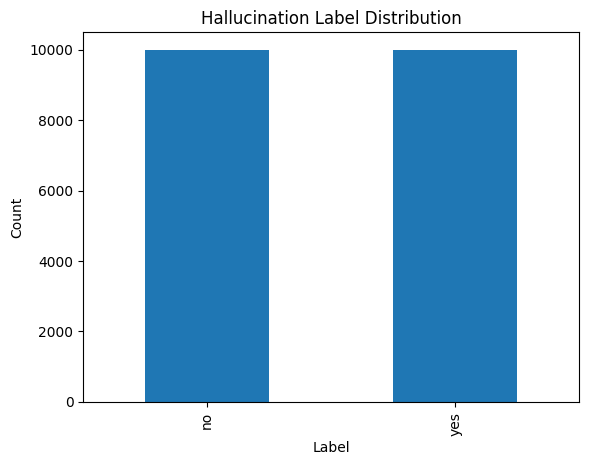

In [105]:
import matplotlib.pyplot as plt

data["ref"].value_counts().plot(kind="bar")

plt.title("Hallucination Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")

plt.show()

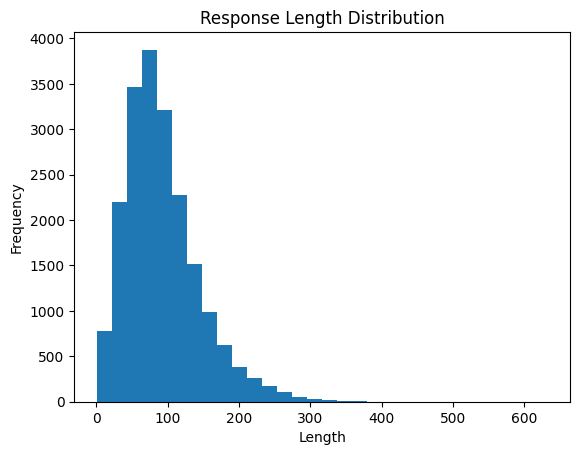

In [106]:
data["response_length"] = data["response"].astype(str).apply(len)

plt.hist(data["response_length"], bins=30)

plt.title("Response Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")

plt.show()

## **Bivariate analysis**

In [107]:
import sys
import subprocess

subprocess.check_call([sys.executable, "-m", "pip", "install", "seaborn"])

0

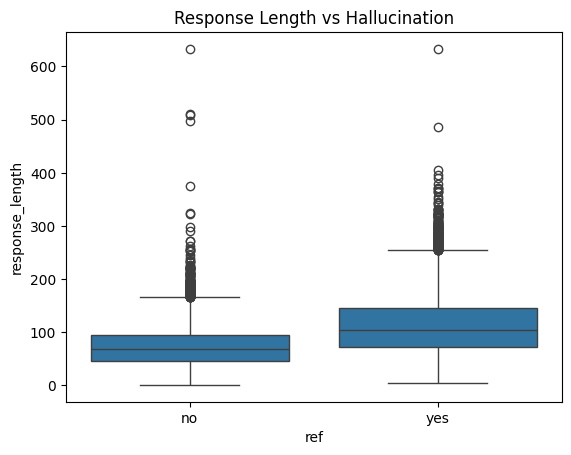

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(x="ref", y="response_length", data=data)
plt.title("Response Length vs Hallucination")
plt.show()

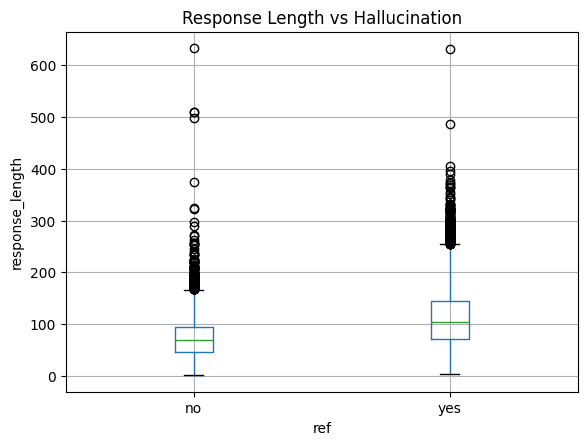

In [109]:
import matplotlib.pyplot as plt

data.boxplot(column="response_length", by="ref")
plt.title("Response Length vs Hallucination")
plt.suptitle("")
plt.xlabel("ref")
plt.ylabel("response_length")
plt.show()

In [110]:
import re

def clean_text(text):

    text = str(text).lower()
    text = re.sub(r"http\S+", " ", text)
    text = re.sub(r"[^a-z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text)

    return text.strip()

data["clean_text"] = data["response"].apply(clean_text)

print(data.head())

                                            response  ref  label  \
0  I like crime fiction! Didn't know RDJ was in t...   no      0   
1  I'm not a fan of crime movies, but I did know ...  yes      1   
2  yes and he also produced White Oleander and it...   no      0   
3  No, I don't think Hunt Lowry was involved in A...  yes      1   
4  Yes, Healing the World is one of my favorite s...   no      0   

   response_length                                         clean_text  
0               84  i like crime fiction didn t know rdj was in th...  
1               88  i m not a fan of crime movies but i did know t...  
2               67  yes and he also produced white oleander and it...  
3              172  no i don t think hunt lowry was involved in a ...  
4               89  yes healing the world is one of my favorite so...  


In [111]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=10000)

X = vectorizer.fit_transform(data["clean_text"])

y = data["label"]

print(X.shape)

(20000, 10000)


## *Train test split*

In [112]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

## **Logistic Regression model**

In [113]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression(max_iter=1000)

model.fit(X_train,y_train)

pred = model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.75      0.80      0.78      1994
           1       0.79      0.74      0.76      2006

    accuracy                           0.77      4000
   macro avg       0.77      0.77      0.77      4000
weighted avg       0.77      0.77      0.77      4000

